In [1]:
%pip install nibabel
%pip install numpy
%pip install matplotlib
%pip install tqdm
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Import Libraries

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import pandas as pd

## Get Image Data

In [3]:
img_dir = "MRI_Seg_FBB10YC/"

In [4]:
img_paths = os.listdir(img_dir)

In [5]:
def pad_zeros(img: np.ndarray) -> np.ndarray:
    """
    Pad zeros to create 128 x 128 image.
    """
    first_dim, second_dim = img.shape

    col_pad = 128 - second_dim
    col_pad_side = col_pad // 2
    col_pad_left, col_pad_right = col_pad_side, col_pad_side
    if col_pad_side * 2 < col_pad:
        col_pad_right += 1
    img = np.concatenate(
        (
            np.zeros((first_dim, col_pad_left)),
            img,
            np.zeros((first_dim, col_pad_right))
        ), axis=1
    )

    row_pad = 128 - first_dim
    row_pad_side = row_pad // 2
    row_pad_top, row_pad_bottom = row_pad_side, row_pad_side
    if row_pad_side  * 2 < row_pad:
        row_pad_bottom += 1
    img = np.concatenate(
        (
            np.zeros((row_pad_top, 128)),
            img,
            np.zeros((row_pad_bottom, 128))
        )
    )

    return img

In [6]:
def get_Y() -> np.ndarray:
    """
    Concatenate 128 x 128 images side by side.
    """
    Y = None

    for i, img_path in enumerate(img_paths):
        img = nib.load(img_dir + img_path)
        img = img.get_fdata()
        img = np.mean(img, axis=2)  # 121 x 121 image.
        img = img[:, ~np.all(img == 0, axis=0)]  # Remove 0 columns.
        img = pad_zeros(img)
        if Y is not None:
            Y = np.concatenate((Y, img), axis=1)
        else:
            Y = img

    return Y

## Orthogonal Dictionary Learning

$\bm{Y}, \bm{X} \in \mathbb{R}^{n \times m}$, $\bm{A} \in O(n)$

Solve $\min_{\bm{q}} \frac{1}{m}\|\bm{q}^T\bm{Y}\|_1$ such that $\|\bm{q}\|_2 = 1$

$n \log(n)$ runs of subgradient method results with $\bm{A} = \{\bm{a}_1,\cdots,\bm{a}_n\}$

Solve $\min_{\bm{A}, \bm{X}} \frac{1}{2}\|\bm{Y} - \bm{A}\bm{X}\|_F^2 + \lambda \|\bm{X}\|_1$ such that $\bm{A} \in O(n)$

In [7]:
def SGM(Y: np.ndarray, niter: int=10000, eps: float=1e-5) -> tuple[np.ndarray, list[float]]:
    """
    Subgradient method.
    """
    objective_fun = lambda q: np.linalg.vector_norm(q.T @ Y, ord=1) /\
        Y.shape[1]
    projection = lambda q, z: z - q * (q.T @ z)
    gf = lambda q: Y @ np.sign(q.T @ Y).T / Y.shape[1]
    rgf = lambda q: projection(q, gf(q))
    rt = lambda z, u: (z + u) / np.linalg.vector_norm(z + u) 

    q = np.random.rand(Y.shape[0], 1)
    q /= np.linalg.vector_norm(q)
    out = np.empty(niter + 1)
    out[0] = objective_fun(q)
    for itr in range(niter):
        grad = rgf(q)
        eta = (itr + 1)**(-3 / 8) / (100 * np.sqrt(itr + 1))
        q = rt(q, -eta * grad)
        out[itr + 1] = objective_fun(q)
        if abs(out[itr + 1] - out[itr]) < eps:
            break
    return q, out[:itr + 2]

In [8]:
def ADM(Y: np.ndarray, A: np.ndarray, lam: float=0.02,
        niter: int=1000, eps: float=1e-5) -> tuple[np.ndarray, np.ndarray]:
    """
    Alternating Direction Method
    """
    objective_fun = lambda A, X:\
        0.5 * np.linalg.matrix_norm(Y - A @ X)**2 +\
            lam * np.linalg.matrix_norm(X, ord=1)

    out_prev = 1e4
    for itr in trange(niter):
        X = np.sign(A.T @ Y) * np.maximum(np.abs(A.T @ Y) - lam, 0)
        U, _, V = np.linalg.svd(Y @ X.T, full_matrices=False)
        A = U @ V
        out = objective_fun(A, X)
        if abs(out - out_prev) < eps:
            break
        out_prev = out
    return A, X

In [9]:
if not os.path.isdir("Plots"):
    os.mkdir("Plots")

 12%|█▏        | 122/1000 [00:02<00:19, 44.78it/s]


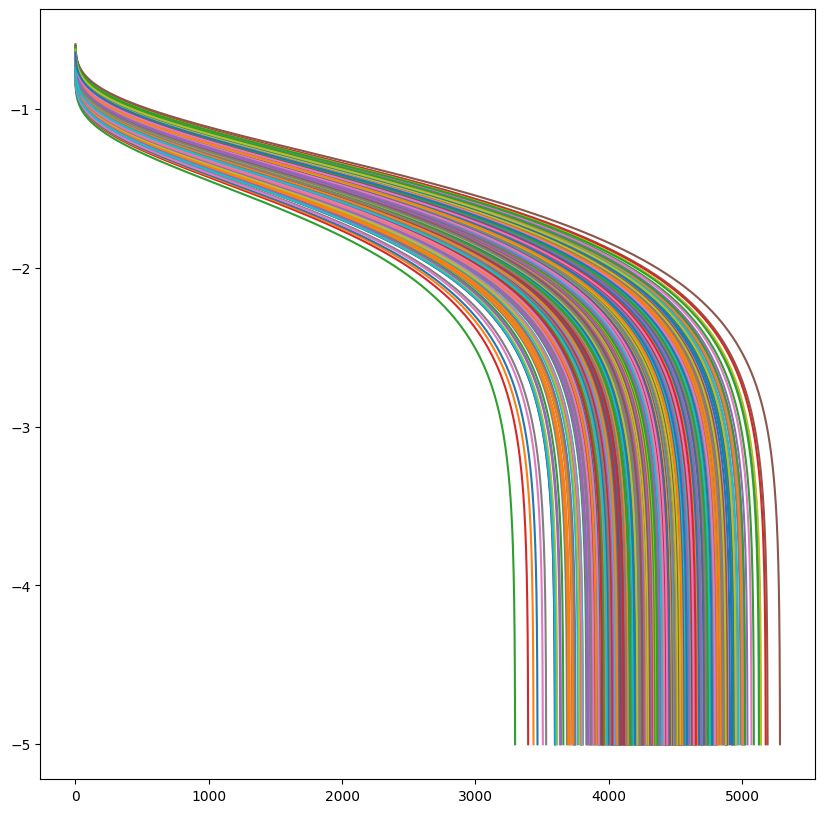

In [10]:
A = None
Y = get_Y()

num_iterations = round(Y.shape[0] * np.log(Y.shape[0]))
plt.subplots(figsize=(10, 10))
for i in trange(num_iterations):
    q_i, out_i = SGM(Y)
    if A is None:
        A = q_i
    else:
        A = np.concatenate((A, q_i), axis=1)
    plt.plot(
        range(len(out_i) - 1),
        np.log10(np.array(out_i[:-1] - out_i[-1]))
    )
plt.savefig(
    "Plots/subgradient_convergence.jpg",
    dpi=500, bbox_inches="tight"
)

for i in trange(num_iterations - Y.shape[0]):
    corr = np.corrcoef(A, rowvar=False)
    col = np.unravel_index(np.argmax(np.triu(corr, 1)), corr.shape)[1]
    A = np.delete(A, col, axis=1)

A_1, X_1 = ADM(Y, A, 0.02)
A_2, X_2 = ADM(Y, A, 0.05)
A_3, X_3 = ADM(Y, A, 0.10)
A_4, X_4 = ADM(Y, A, 0.20)

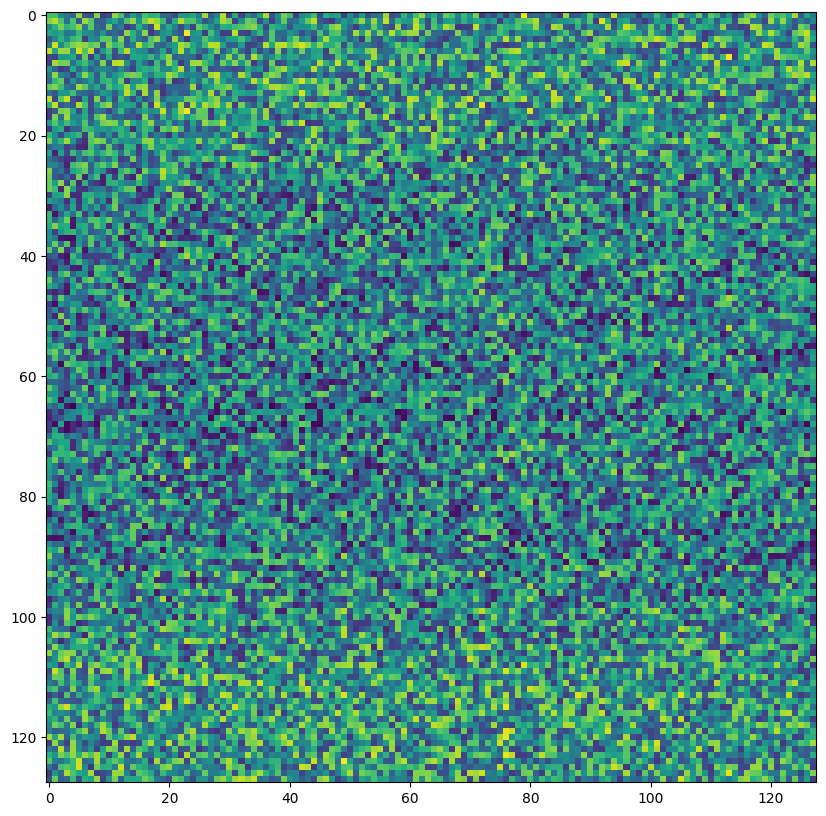

In [11]:
plt.subplots(figsize=(10, 10))
plt.imshow(A)
plt.savefig("Plots/original_A.jpg", dpi=500, bbox_inches="tight")
plt.show()

In [12]:
def calculate_sparsity(X_i: np.ndarray) -> tuple[float, int]:
    zeros = 128**2 - np.count_nonzero(X_i)

    # Remove 0 columns.
    zero_cols = np.all(X_i == 0, axis=0)
    X_i = X_i[:, ~zero_cols]

    sparsity = 0
    for i in range(X_i.shape[1]):
        col_vector = X_i[:, [[i]]]
        l1 = np.linalg.vector_norm(col_vector, ord=1)
        l2 = np.linalg.vector_norm(col_vector, ord=2)
        sparsity += (l1 / l2)
    sparsity /= X_i.shape[1]

    return sparsity, zeros

In [13]:
def plot_mri(Y: np.ndarray, A: list[np.ndarray], X: list[np.ndarray],
             lam: list[float], i: int) ->\
        tuple[str, list[int], int, list[float], list[float]]:
    Y_i = Y[:, i * 128:(i + 1) * 128]

    zeros_X_list = []
    zeros_Y = 128**2 - np.count_nonzero(Y_i)
    sparsity_list = []
    error_list = []

    _, ax = plt.subplots(1, 1 + len(A), figsize=(20, 20))
    ax[0].imshow(Y_i.T)
    ax[0].set_title("Original")

    print("Image:", img_paths[i])
    for j, (A_ij, X_ij, lam_j) in enumerate(zip(A, X, lam)):
        X_i = X_ij[:, i * 128:(i + 1) * 128]
        Y_tilde_i = A_ij @ X_i

        error = np.linalg.matrix_norm(Y_i - Y_tilde_i, ord=2)
        sparsity, zeros_X = calculate_sparsity(X_i)
        
        zeros_X_list.append(zeros_X)
        sparsity_list.append(sparsity)
        error_list.append(error)
        
        print()
        print("Lambda:", lam_j)
        print("Number of Zeros X:", zeros_X)
        print("Number of Zeros Y:", zeros_Y)
        print("Sparsity of X:", sparsity)
        print("Error of AX:", error)

        ax[j + 1].imshow(Y_tilde_i.T)
        ax[j + 1].set_title("Reconstructed lam=" + str(lam_j))
    
    plt.savefig(
        "Plots/" + img_paths[i].rstrip(".nii") + "_original_reconstructed.jpg",
        dpi=500, bbox_inches="tight"
    )
    plt.show()

    return img_paths[i], zeros_X_list, zeros_Y, sparsity_list, error_list

In [14]:
if not os.path.isdir("Tables"):
    os.mkdir("Tables")

Image: mwc1MR_1001_2_20160701130924.nii

Lambda: 0.02
Number of Zeros X: 13931
Number of Zeros Y: 7295
Sparsity of X: 1.7431791731671078
Error of AX: 0.3471628899723772

Lambda: 0.05
Number of Zeros X: 15404
Number of Zeros Y: 7295
Sparsity of X: 1.5031668782280794
Error of AX: 0.7323302897240691

Lambda: 0.1
Number of Zeros X: 15888
Number of Zeros Y: 7295
Sparsity of X: 1.356805323290025
Error of AX: 1.3009656308678876

Lambda: 0.2
Number of Zeros X: 16083
Number of Zeros Y: 7295
Sparsity of X: 1.1970756036032808
Error of AX: 2.546848565287305


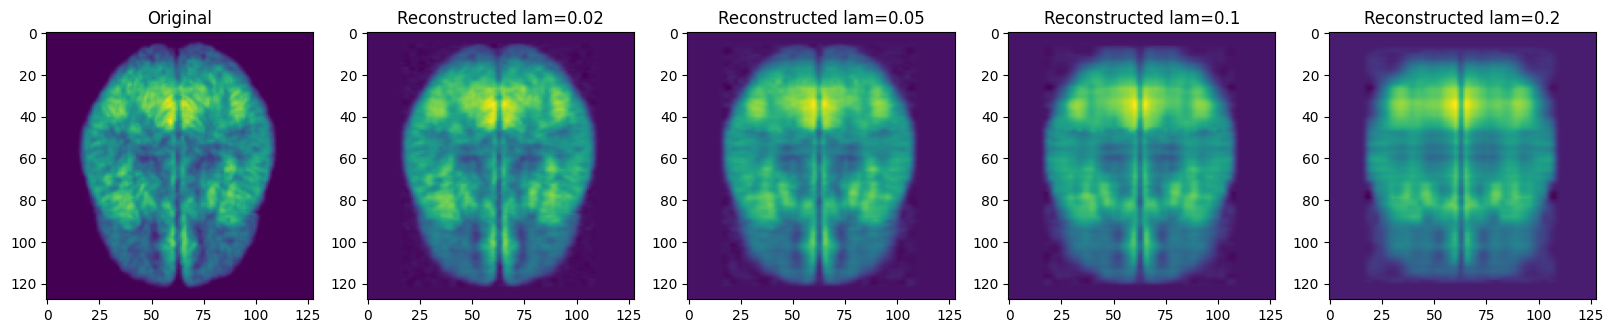

Image: mwc1MR_1002_2_20160715122634.nii

Lambda: 0.02
Number of Zeros X: 14044
Number of Zeros Y: 7223
Sparsity of X: 1.7193934118698262
Error of AX: 0.3720490556424701

Lambda: 0.05
Number of Zeros X: 15503
Number of Zeros Y: 7223
Sparsity of X: 1.4789812323579636
Error of AX: 0.778378446652677

Lambda: 0.1
Number of Zeros X: 15916
Number of Zeros Y: 7223
Sparsity of X: 1.3328550902148733
Error of AX: 1.3434272964241007

Lambda: 0.2
Number of Zeros X: 16117
Number of Zeros Y: 7223
Sparsity of X: 1.1614401618303665
Error of AX: 2.476152550361061


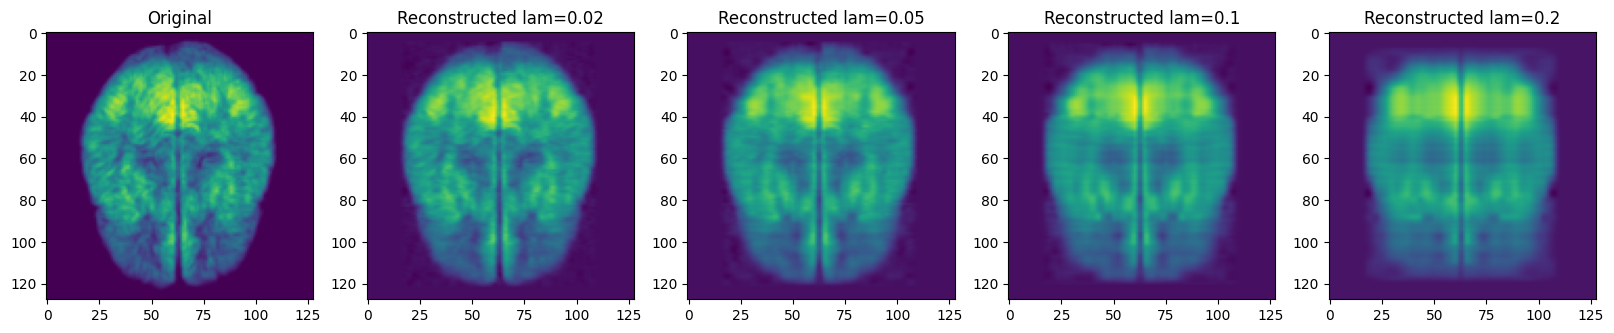

Image: mwc1MR_1003_5_20160914100618.nii

Lambda: 0.02
Number of Zeros X: 13821
Number of Zeros Y: 7225
Sparsity of X: 1.7475913189684111
Error of AX: 0.3617729104336774

Lambda: 0.05
Number of Zeros X: 15401
Number of Zeros Y: 7225
Sparsity of X: 1.4990942231079403
Error of AX: 0.7640964161100794

Lambda: 0.1
Number of Zeros X: 15887
Number of Zeros Y: 7225
Sparsity of X: 1.358408668783531
Error of AX: 1.3661182221472397

Lambda: 0.2
Number of Zeros X: 16090
Number of Zeros Y: 7225
Sparsity of X: 1.1871479046305773
Error of AX: 2.5871650707653133


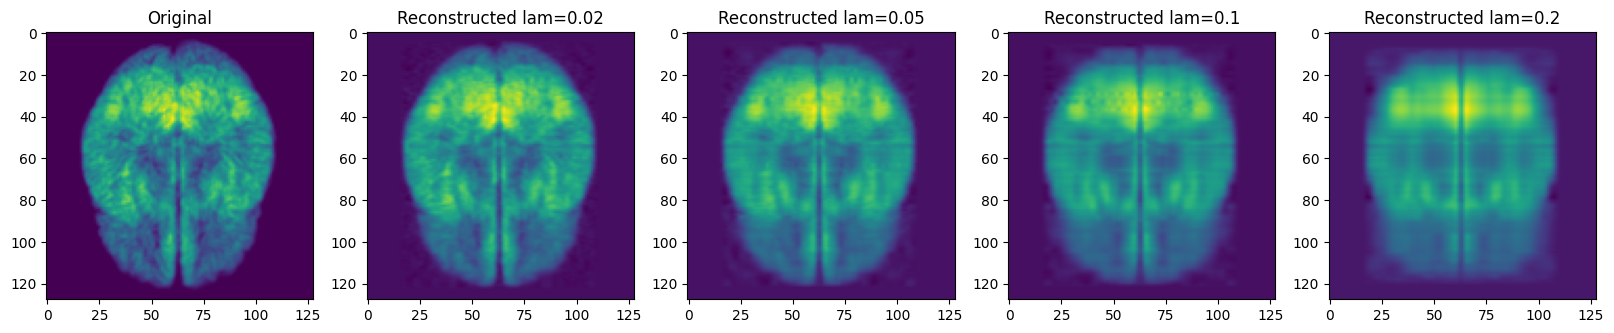

Image: mwc1MR_1004_2_20160805130611.nii

Lambda: 0.02
Number of Zeros X: 14009
Number of Zeros Y: 7342
Sparsity of X: 1.7442044799403134
Error of AX: 0.36579559072147244

Lambda: 0.05
Number of Zeros X: 15529
Number of Zeros Y: 7342
Sparsity of X: 1.4724135530177964
Error of AX: 0.7240049511345553

Lambda: 0.1
Number of Zeros X: 15945
Number of Zeros Y: 7342
Sparsity of X: 1.3349819318048493
Error of AX: 1.3077368630701756

Lambda: 0.2
Number of Zeros X: 16127
Number of Zeros Y: 7342
Sparsity of X: 1.1648481064492378
Error of AX: 2.469186191682909


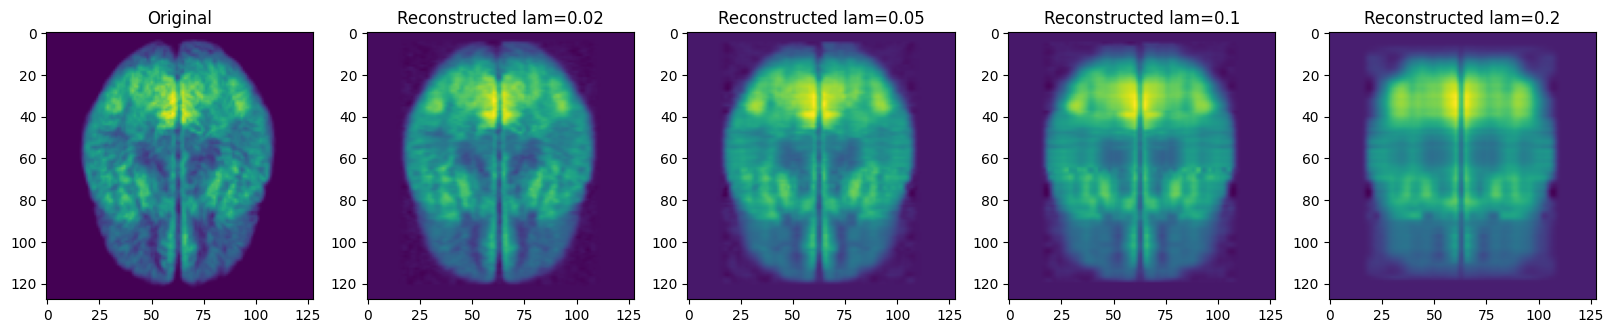

Image: mwc1MR_1005_2_20160722123224.nii

Lambda: 0.02
Number of Zeros X: 13780
Number of Zeros Y: 7143
Sparsity of X: 1.8022684039418826
Error of AX: 0.35826658582694715

Lambda: 0.05
Number of Zeros X: 15352
Number of Zeros Y: 7143
Sparsity of X: 1.5287788819667594
Error of AX: 0.770976981297853

Lambda: 0.1
Number of Zeros X: 15872
Number of Zeros Y: 7143
Sparsity of X: 1.366054786029967
Error of AX: 1.3455613659502415

Lambda: 0.2
Number of Zeros X: 16092
Number of Zeros Y: 7143
Sparsity of X: 1.2009366137445947
Error of AX: 2.5235183550844904


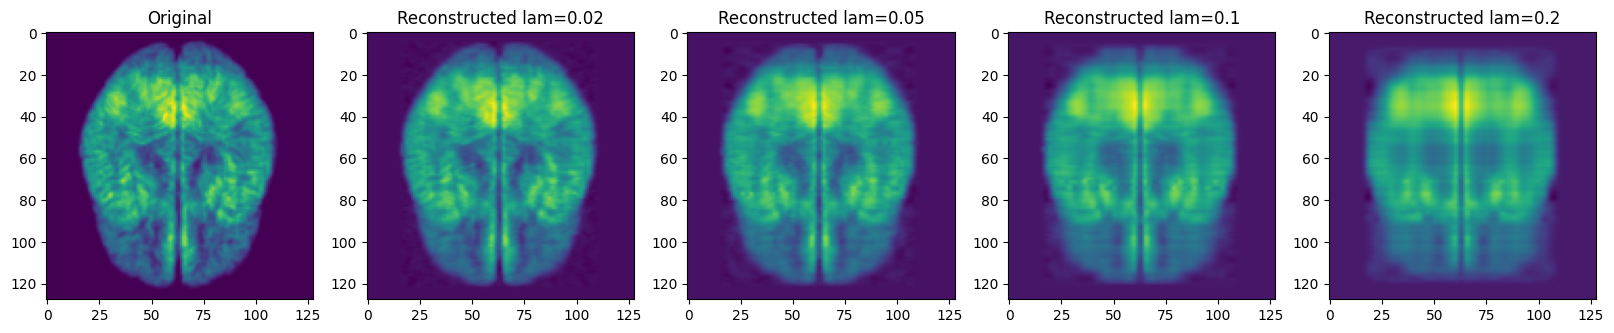

Image: mwc1MR_1007_2_20160719124145.nii

Lambda: 0.02
Number of Zeros X: 14147
Number of Zeros Y: 7191
Sparsity of X: 1.7055308566474163
Error of AX: 0.3466324334443457

Lambda: 0.05
Number of Zeros X: 15508
Number of Zeros Y: 7191
Sparsity of X: 1.4664993785516145
Error of AX: 0.7436226053571539

Lambda: 0.1
Number of Zeros X: 15941
Number of Zeros Y: 7191
Sparsity of X: 1.3212435725845053
Error of AX: 1.3234049701636856

Lambda: 0.2
Number of Zeros X: 16133
Number of Zeros Y: 7191
Sparsity of X: 1.1623510722829875
Error of AX: 2.434742313522222


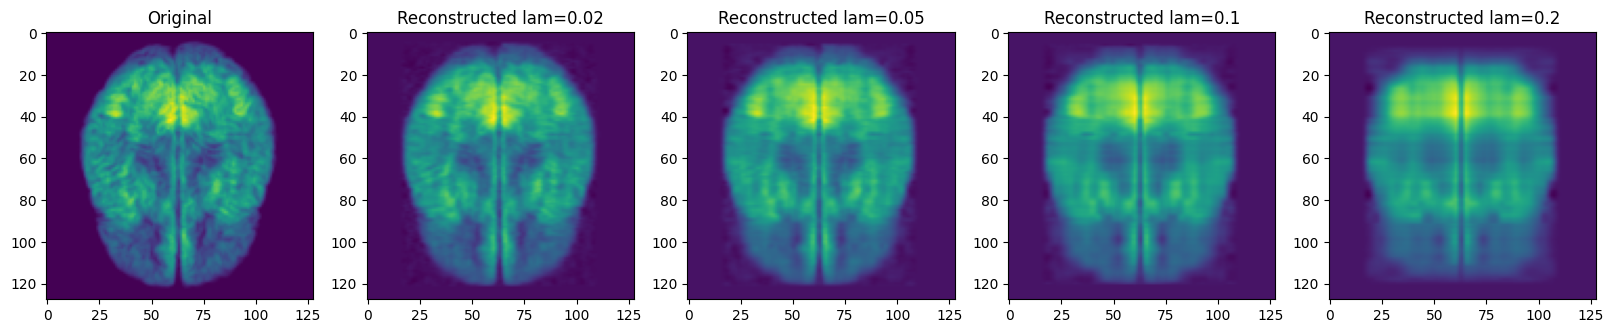

Image: mwc1MR_1011_2_20160823124322.nii

Lambda: 0.02
Number of Zeros X: 13896
Number of Zeros Y: 7070
Sparsity of X: 1.7303585849131056
Error of AX: 0.3616408835344397

Lambda: 0.05
Number of Zeros X: 15378
Number of Zeros Y: 7070
Sparsity of X: 1.4966960439354564
Error of AX: 0.8052835730358316

Lambda: 0.1
Number of Zeros X: 15866
Number of Zeros Y: 7070
Sparsity of X: 1.3691456974044374
Error of AX: 1.4052074681238094

Lambda: 0.2
Number of Zeros X: 16061
Number of Zeros Y: 7070
Sparsity of X: 1.2088243181006055
Error of AX: 2.6752950946878906


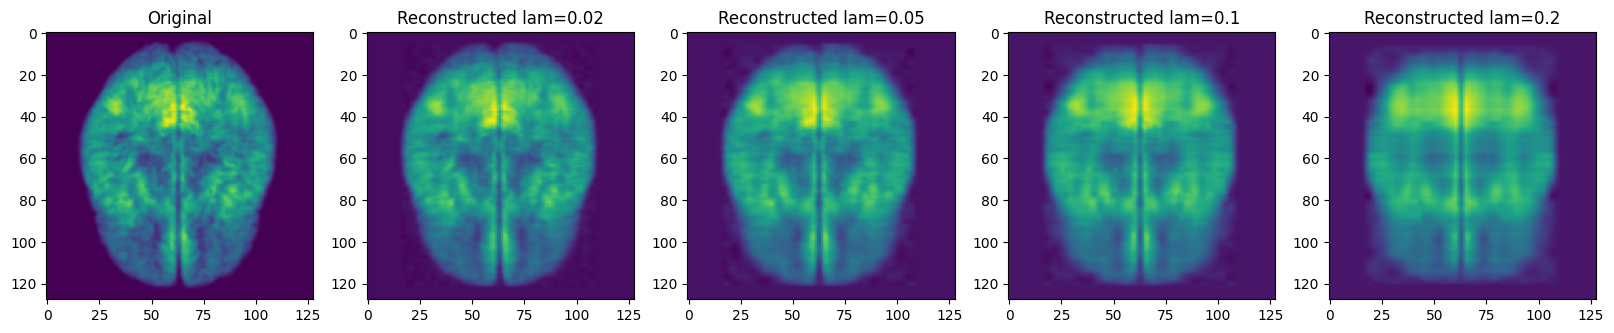

Image: mwc1MR_1012_2_20160722115010.nii

Lambda: 0.02
Number of Zeros X: 13878
Number of Zeros Y: 7333
Sparsity of X: 1.7778145873753308
Error of AX: 0.35062388000099737

Lambda: 0.05
Number of Zeros X: 15368
Number of Zeros Y: 7333
Sparsity of X: 1.521956671008085
Error of AX: 0.7649548954711217

Lambda: 0.1
Number of Zeros X: 15862
Number of Zeros Y: 7333
Sparsity of X: 1.3776573453812544
Error of AX: 1.37406456240976

Lambda: 0.2
Number of Zeros X: 16083
Number of Zeros Y: 7333
Sparsity of X: 1.2057601869240337
Error of AX: 2.618285537504196


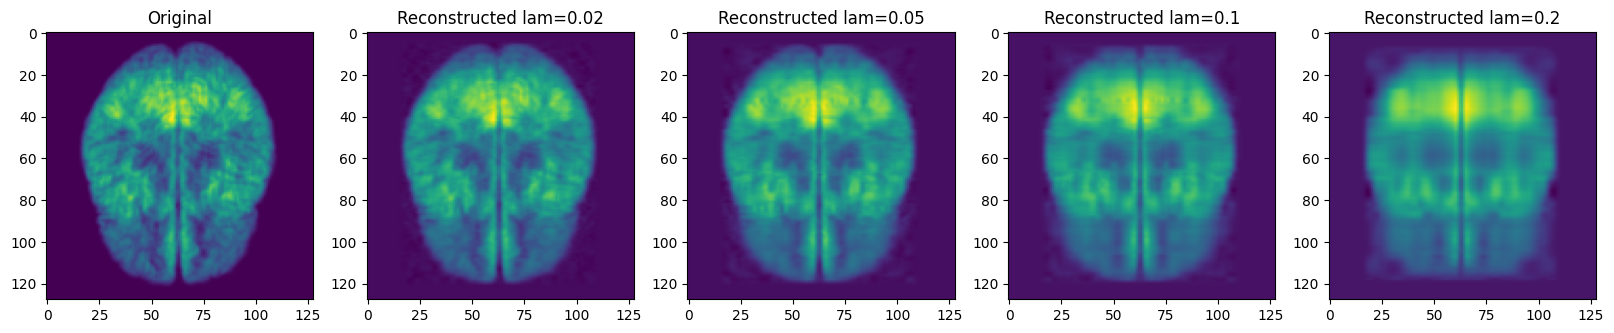

Image: mwc1MR_1017_2_20160902140329.nii

Lambda: 0.02
Number of Zeros X: 13787
Number of Zeros Y: 7275
Sparsity of X: 1.7795865878666102
Error of AX: 0.34889443613207277

Lambda: 0.05
Number of Zeros X: 15341
Number of Zeros Y: 7275
Sparsity of X: 1.5314173938718294
Error of AX: 0.7765118542056196

Lambda: 0.1
Number of Zeros X: 15858
Number of Zeros Y: 7275
Sparsity of X: 1.3797675529059956
Error of AX: 1.3583695418059167

Lambda: 0.2
Number of Zeros X: 16078
Number of Zeros Y: 7275
Sparsity of X: 1.2110153284435528
Error of AX: 2.5930521165828737


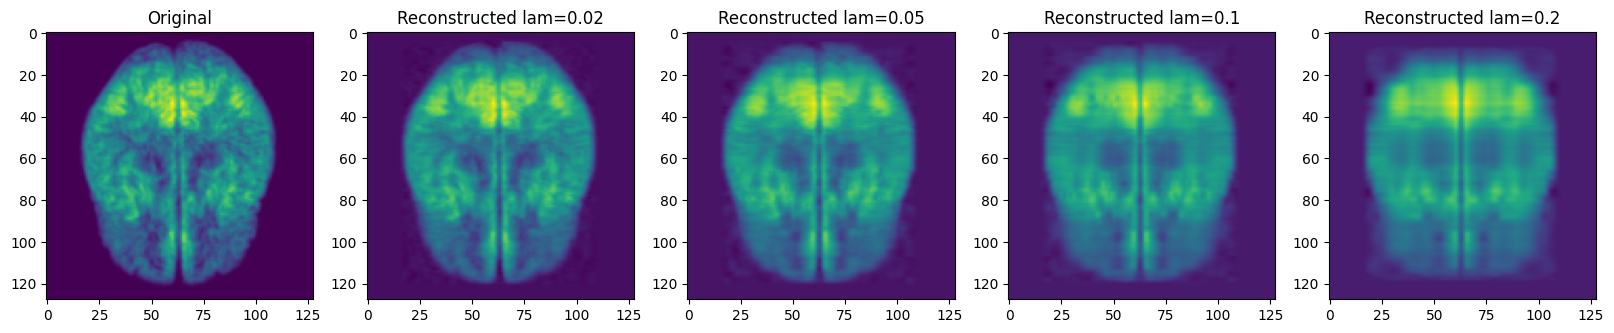

Image: mwc1MR_1021_2_20160916100329.nii

Lambda: 0.02
Number of Zeros X: 13917
Number of Zeros Y: 7017
Sparsity of X: 1.7501294936624177
Error of AX: 0.34013435731137254

Lambda: 0.05
Number of Zeros X: 15345
Number of Zeros Y: 7017
Sparsity of X: 1.5084088520158083
Error of AX: 0.7767494971530096

Lambda: 0.1
Number of Zeros X: 15837
Number of Zeros Y: 7017
Sparsity of X: 1.3632354763594503
Error of AX: 1.3813773995153882

Lambda: 0.2
Number of Zeros X: 16063
Number of Zeros Y: 7017
Sparsity of X: 1.1964036352860004
Error of AX: 2.592583988128893


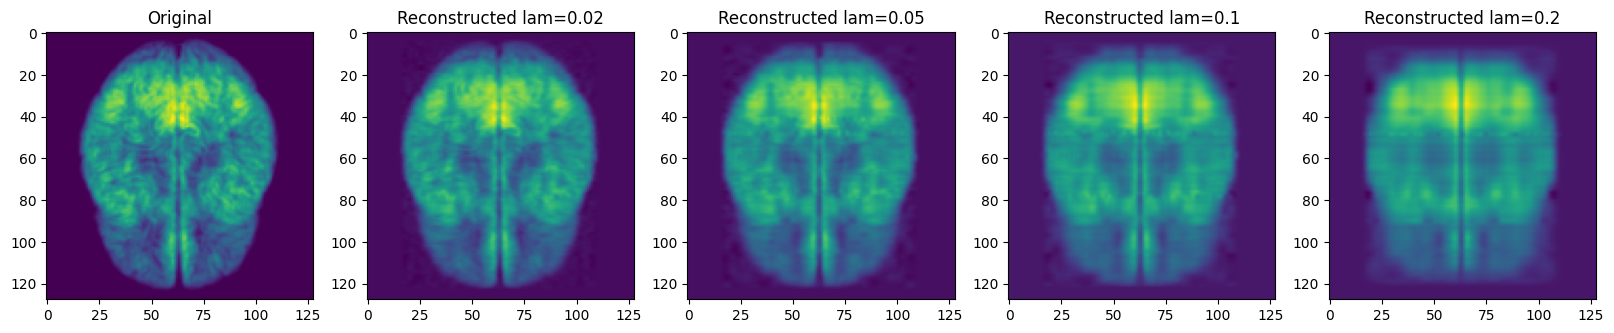

In [15]:
img_strs, zero_X_strs, zero_Y, zero_Y_strs, sparsity_strs, error_strs =\
    [], [], [], [], [], []
lam = [0.02, 0.05, 0.10, 0.20]

for i in range(10):
    img_str, zeros_X_list, zeros_Y, sparsity_list, error_list =\
        plot_mri(Y, [A_1, A_2, A_3, A_4], [X_1, X_2, X_3, X_4], lam, i)
    img_strs.extend([img_str] * 4)
    zero_X_strs.extend(zeros_X_list)
    zero_Y.extend([zeros_Y] * 4)
    zero_Y_strs.append(zeros_Y)
    sparsity_strs.extend(sparsity_list)
    error_strs.extend(error_list)

In [16]:
reconstructed_image_avg = pd.DataFrame(
    {
        "Lambda": lam,
        "Average Number of Zeros X": [
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(0, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(0, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(1, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(1, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(2, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(2, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(3, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(3, len(zero_X_strs), 4)]))
                ]
            )
        ],
        "Average Number of Zeros Y": [
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            )
        ],
        "Average Sparsity": [
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(0, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(0, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(1, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(1, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(2, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(2, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(3, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(3, len(sparsity_strs), 4)]))
                ]
            )
        ],
        "Average Error": [
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(0, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(0, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(1, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(1, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(2, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(2, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(3, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(3, len(error_strs), 4)]))
                ]
            )
        ]
    }
)

reconstructed_image_avg.to_csv("Tables/reconstructed_image_avg.csv", index=None)
reconstructed_image_avg

,Lambda,Average Number of Zeros X,Average Number of Zeros Y,Average Sparsity,Average Error
0,0.02,13921.0 +- 111.5239884509158,7211.4 +- 102.99339784665811,1.7500056898352423 +- 0.027869313873512574,0.3552973023020173 +- 0.009569887962502374
1,0.05,15412.9 +- 68.98180919633813,7211.4 +- 102.99339784665811,1.5007413108061332 +- 0.021701252094541577,0.7636909510141969 +- 0.023014400439525667
2,0.10,15887.2 +- 34.28352373954579,7211.4 +- 102.99339784665811,1.356015544475889 +- 0.01884701695631693,1.3506233320478205 +- 0.0314614198720042
3,0.20,16092.7 +- 23.853930493736243,7211.4 +- 102.99339784665811,1.1895802931295236 +- 0.018639154818926577,2.5516829783607156 +- 0.0716668928299199


In [17]:
reconstructed_image_data = pd.DataFrame(
    {
        "Image": img_strs, "Number of Zeros X": zero_X_strs,
        "Number of Zeros Y": zero_Y, "Sparsity": sparsity_strs,
        "Error": error_strs, "Lambda": lam * 10
    }
)
reconstructed_image_data.to_csv('Tables/reconstructed_image_data.csv', index=None)